# Proyecto Gold Recovery


## Importamos librerias y datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [36]:
train = pd.read_csv('/datasets/gold_recovery_train.csv', index_col= 'date', parse_dates= True)
test = pd.read_csv('/datasets/gold_recovery_test.csv', index_col= 'date', parse_dates= True)
full = pd.read_csv('/datasets/gold_recovery_full.csv', index_col= 'date', parse_dates= True)

## Analizamos los datos 

**Datos importantes antes de iniciar**

Los datos se indexan con la fecha y la hora de adquisición (date). Los parámetros cercanos en el tiempo suelen ser similares.

Algunos parámetros no están disponibles porque fueron medidos o calculados mucho más tarde. Por eso, algunas de las características que están presentes en el conjunto de entrenamiento pueden estar ausentes en el conjunto de prueba. El conjunto de prueba tampoco contiene objetivos.

El dataset fuente contiene los conjuntos de entrenamiento y prueba con todas las características.

Tienes a tu disposición los datos en bruto que solamente fueron descargados del almacén de datos. Antes de construir el modelo, comprueba que los datos sean correctos. Para ello, utiliza nuestras instrucciones.

In [3]:
print("Dataset de entrenamiento")
print(train.info())
print()
print("Dataset de prueba")
print(test.info())
print()
print("Dataset fuente")
print(full.info())

Dataset de entrenamiento
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16860 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16788 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   final.output.concentrate_sol                        16490 non-null  float64
 3   final.output.concentrate_au                         16789 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag                                16794 non-null  float64
 6   final.output.tail_pb                                16677 non-null  float64
 7   final.output.tail_sol                               16715 non-null  float64
 8   final.output.tai

**Observaciones:**

Tal y como vemos en las instrucciones, tenemos valores faltantes e incluso en el dataset "test", hace falta las columnas rougher.output.recovery y final.output.recovery. 

El conjunto de entrenamiento sí incluye las columnas objetivo, pero contiene muchos valores nulos, especialmente en:
- rougher.output.recovery (2,573 faltantes)
- final.output.recovery (1,521 faltantes)

Los 3 DF usan DatetimeIndex, lo cual es bueno para tareas de series de tiempo o validación basada en tiempo.

In [74]:
# Verificación del cálculo de recuperación
F = full['rougher.input.feed_au']
C = full['rougher.output.concentrate_au']
T = full['rougher.output.tail_au']

# Cálculo manual
recovery_calculated = (C * (F - T)) / (F * (C - T)) * 100

# Comparación con columna original
recovery_actual = full['rougher.output.recovery']

# Error absoluto medio
recovery_diff = abs(recovery_actual - recovery_calculated)
print(f'Diferencia media entre recovery real y calculado: {recovery_diff.mean():.4f}')

Diferencia media entre recovery real y calculado: 0.0000


**Verificación del cálculo de recuperación**

Se verificó que la columna `rougher.output.recovery` esté correctamente calculada utilizando la fórmula estándar de recuperación metalúrgica.  
La diferencia media entre el valor calculado y el proporcionado es prácticamente cero, por lo que se confirma que los datos son correctos.

## Procesamiento de datos

In [37]:
# Revisamos nuevamente el tamaño de nuestros dataframes
print(train.shape, test.shape, full.shape)

(16860, 86) (5856, 52) (22716, 86)


Dataset full = 22716 (100% de los datos)

Dataset train = 16860 (75% de los datos)

Dataset test = 5856 (25% de los datos)

In [38]:
#Revisamos las columnas faltantes
missing_cols = set(train.columns) - set(test.columns)
print("Columnas ausentes en test:")
print(missing_cols)

Columnas ausentes en test:
{'rougher.output.tail_au', 'final.output.concentrate_au', 'rougher.output.concentrate_pb', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'final.output.recovery', 'final.output.concentrate_pb', 'final.output.tail_ag', 'primary_cleaner.output.concentrate_ag', 'secondary_cleaner.output.tail_sol', 'rougher.output.concentrate_au', 'primary_cleaner.output.tail_au', 'rougher.calculation.au_pb_ratio', 'rougher.calculation.sulfate_to_au_concentrate', 'final.output.tail_au', 'rougher.output.tail_ag', 'rougher.output.recovery', 'secondary_cleaner.output.tail_au', 'rougher.output.tail_sol', 'secondary_cleaner.output.tail_pb', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'secondary_cleaner.output.tail_ag', 'final.output.concentrate_ag', 'final.output.tail_sol', 'rougher.output.tail_pb', 'primary_cleaner.output.concentrate_au', 'rougher.output.concentrate_ag', 'final.output.concentrate_sol', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.concent

**Comentarios**

Como vemos y ya habiamos visto anteriormente, tenemos las columnas "rougher.output.recovery" y "final.output.recovery" faltantes en el DF de test. Lo que haremos más adelante será conservar en el DF train solo las columnas en común + las columnas objetivo ("rougher.output.recovery" y "final.output.recovery"), para asi tener la misma cantidad de columnas y poder entrenar adecuadamente el modelo.

In [39]:
print(train.shape)
print(test.shape)

(16860, 86)
(5856, 52)


Como los datos están indexados por fecha y hora (date) y algunos parámetros faltan en el conjunto de prueba (porque se calcularon más tarde), debemos asegurarnos que el indice "date" esté correctamente establecido y ordenado, manejar los valores ausentes de manera apropiada considerando la secuencia temporal y asegurarnos que solo se usen características comunes al entrenar el modelo.

In [40]:
# Ordenamos por fecha 
train = train.sort_index()
test = test.sort_index()

In [72]:
#Buscamos cuantas son las columnas que están presentes en ambos dataframes (train y test) 
common_columns = train.columns.intersection(test.columns)
print(f"Columnas comunes: {len(common_columns)}")

Columnas comunes: 52


In [42]:
#Analizamos los valores faltantes 
missing_train = train.isna().mean().sort_values(ascending=False)
missing_test = test.isna().mean().sort_values(ascending=False)

print("Valores faltantes (train):\n", missing_train[missing_train > 0])
print()
print("Valores faltantes (test):\n", missing_test[missing_test > 0])

Valores faltantes (train):
 rougher.output.recovery                               0.152610
rougher.output.tail_ag                                0.133452
rougher.output.tail_sol                               0.133393
rougher.output.tail_au                                0.133393
secondary_cleaner.output.tail_sol                     0.117794
                                                        ...   
primary_cleaner.state.floatbank8_b_level              0.001601
primary_cleaner.state.floatbank8_c_level              0.001601
primary_cleaner.state.floatbank8_d_level              0.001601
rougher.calculation.sulfate_to_au_concentrate         0.001601
rougher.calculation.floatbank10_sulfate_to_au_feed    0.001601
Length: 85, dtype: float64

Valores faltantes (test):
 rougher.input.floatbank11_xanthate            0.060280
primary_cleaner.input.sulfate                 0.051571
primary_cleaner.input.depressant              0.048497
rougher.input.floatbank10_sulfate             0.043887
prim

**Observaciones**

- Ambos dataframes presentan valores ausentes
- La mayoria de los valores faltantes están por debajo del 12%, pero algunos superan el 5%, lo cual puede afectar al modelo si no se maneja adecuadamente.
- Como los datos están indexados por fecha, los valores cercanos en el tiempo son similares, por lo que rellenar hacia adelante o hacia atrás es razonable.


Dado que se trata de un proceso industrial continuo con alta correlación temporal, la opcion más apropiada es que los valores faltantes se completen usando el dato anterior o posterior más cercano, que se respete la continuidad temporal y que no se introduzca sesgo artificial usando la media o la mediana, lo que podría "suavizar" la señal útil.

In [43]:
# Rellenamos hacia adelante, y luego hacia atrás para los primeros valores faltantes
train = train.ffill().bfill()
test = test.ffill().bfill()

In [44]:
#Verificamos que ya no hayan datos ausentes
print(train.isnull().sum().sum())  # Debe dar 0
print(test.isnull().sum().sum())   # Debe dar 0

0
0


In [45]:
#Nos aseguramos de tener nuestras columnas objetivo y que no presentan valores nulos
target_columns = ['rougher.output.recovery', 'final.output.recovery']

In [46]:
print(train[target_columns].isnull().sum())

rougher.output.recovery    0
final.output.recovery      0
dtype: int64


## Analisis de metales

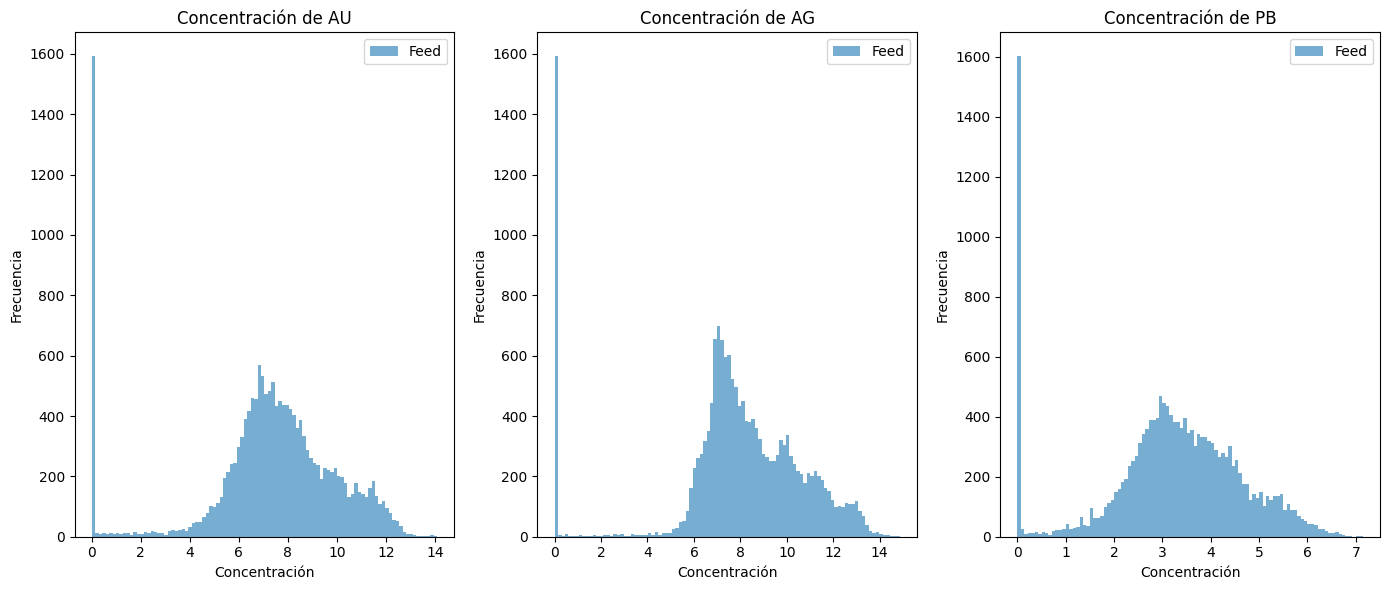

In [47]:
# Lista de metales a analizar
metales = ['au', 'ag', 'pb']

# Diccionario de etapas con prefijos en el dataset
etapas = {
    'Feed': 'rougher.input.feed_',
    'Rougher Output': 'rougher.output.',
    'Final Output': 'final.output.'
}

#Gráfico
plt.figure(figsize=(14, 6))

for i, metal in enumerate(metales, 1):
    plt.subplot(1, 3, i)
    
    for etapa_nombre, prefijo in etapas.items():
        columna = prefijo + metal
        if columna in train.columns:
            train[columna].plot(kind='hist', bins=100, alpha=0.6, label=etapa_nombre)
    
    plt.title(f'Concentración de {metal.upper()}')
    plt.xlabel('Concentración')
    plt.ylabel('Frecuencia')
    plt.legend()

plt.tight_layout()
plt.show()

**Observaciones**

Concentración de AU (oro)
- Distribución principal: entre 5 y 10 unidades de concentración.
- Pico más alto: entre 7 y 8, lo que indica que es el valor más frecuente.
- Anomalía visible: hay un pico muy alto en 0 , eso indica que muchos registros tienen concentración 0 de oro, lo cual no es esperable en materia prima si el objetivo es extraer oro.

Concentración de AG (plata)
- Distribución principal: entre 4 y 12 unidades, con el pico más frecuente cerca de 7.
- Anomalía igual que en el oro: muchos valores en 0.

Concentración de PB (plomo)
- Distribución más estrecha: entre 2 y 6 unidades.
- Pico más alto: cerca de 3.5.
- También hay un pico significativo en 0

**Conclusión general**

Los tres metales muestran un patrón común: una distribución normal esperable + un pico en 0, que no es normal.
Es probable que esos ceros representen valores erróneos o perdidos, especialmente si:
- No existen concentraciones naturales de 0.
- Los datos fueron imputados mal.
- Los sensores no captaron el valor (NaN convertido a 0).

In [48]:
# Buscamos cuántos valores exactamente en 0 hay
print((train['rougher.input.feed_au'] == 0).sum())
print((train['rougher.input.feed_ag'] == 0).sum())
print((train['rougher.input.feed_pb'] == 0).sum())

1213
1213
1222


In [49]:
#Eliminamos las filas donde cualquiera de estas concentraciones sea 0
cols_to_check = ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb']
train = train[~(train[cols_to_check] == 0).any(axis=1)]

In [50]:
#Revisamos nuevamente
print((train['rougher.input.feed_au'] == 0).sum())
print((train['rougher.input.feed_ag'] == 0).sum())
print((train['rougher.input.feed_pb'] == 0).sum())

0
0
0


In [51]:
print(train.shape)
print(test.shape)

(15638, 86)
(5856, 52)


## Separamos caracteristicas y objetivos

In [52]:
# Columnas objetivo
target_columns = ['rougher.output.recovery', 'final.output.recovery']

# Asegurar que no hay NaNs en las columnas objetivo de train
train = train.dropna(subset=target_columns)

# Seleccionar solo las columnas que existen en test
features = [col for col in test.columns if col in train.columns]

# Filtrar train para que tenga solo las columnas comunes + columnas objetivo
train = train[features + target_columns].dropna()

# Asegurar que test tenga solo las columnas comunes
test = test[features]

# Llenar posibles NaNs en test si los hay (opcional)
test = test.fillna(method='ffill').fillna(method='bfill')

# Mostrar shapes
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (15638, 54)
Test shape: (5856, 52)


In [57]:
features_train = train.drop(columns=['rougher.output.recovery', 'final.output.recovery'])
target_rougher = 'rougher.output.recovery'
target_final = 'final.output.recovery'

In [58]:
features_test = test

In [59]:
print(features_train.shape)
print(features_test.shape)

(15638, 52)
(5856, 52)


## Métrica SMAPE

In [60]:
def smape(target, prediction):
    denominator = (abs(target) + abs(prediction)) / 2
    diff = abs(target - prediction) / denominator
    return np.mean(diff) * 100

In [61]:
def final_smape(rougher_true, rougher_pred, final_true, final_pred):
    smape_rougher = smape(rougher_true, rougher_pred)
    smape_final = smape(final_true, final_pred)
    return 0.25 * smape_rougher + 0.75 * smape_final

## Entrenamos diferentes modelos

In [62]:
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer 
from sklearn.model_selection import cross_val_score, KFold

In [63]:
smape_scorer = make_scorer(smape, greater_is_better=False)

In [64]:
models = {
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators= 20),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor()
}

In [65]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [66]:
for name, model in models.items():
    print(f"\n Evaluando modelo: {name}")

    # Rougher recovery
    score_rougher = cross_val_score(
        model, features_train, targets['rougher.output.recovery'], 
        scoring=smape_scorer, cv=cv
    )
    print(f" - sMAPE rougher (media): {-np.mean(score_rougher):.2f}")

    # Final recovery
    score_final = cross_val_score(
        model, features_train, targets['final.output.recovery'], 
        scoring=smape_scorer, cv=cv
    )
    print(f" - sMAPE final (media): {-np.mean(score_final):.2f}")

     # sMAPE combinado (con ponderación 25% rougher, 75% final)
    smape_comb = 0.25 * (-np.mean(score_rougher)) + 0.75 * (-np.mean(score_final))
    print(f"  sMAPE combinada: {smape_comb:.2f}")


 Evaluando modelo: Random Forest
 - sMAPE rougher (media): 9.29
 - sMAPE final (media): 8.10
  sMAPE combinada: 8.40

 Evaluando modelo: Linear Regression
 - sMAPE rougher (media): 11.86
 - sMAPE final (media): 11.25
  sMAPE combinada: 11.40

 Evaluando modelo: Decision Tree
 - sMAPE rougher (media): 9.04
 - sMAPE final (media): 10.95
  sMAPE combinada: 10.47


**Observaciones:**

El mejor modelo según la métrica combinada de sMAPE es el Random Forest, con un sMAPE combinada de 8.40. ¿Por qué es mejor? Valores más bajos significan mejores predicciones. Un modelo es mejor si su sMAPE combianda es má baja, por que eso significa que cometió menos errores porcentuales en promedio y logró mejores predicciones tanto en la etapa intermedia como final, con más énfasis en el resultado final.

Además:

- Linear Regression tiene un rendimiento claramente inferior.
- Decision Tree es competitivo, pero ligeramente peor que Random Forest.

## Entrenamos el modelo final

In [68]:
print(features_train.shape)
print(features_test.shape)

(15638, 52)
(5856, 52)


In [ ]:
# Entrenamos los modelos en todo el conjunto de entrenamiento
final_model = RandomForestRegressor(n_estimators=20, random_state=42)
final_model.fit(features_train, train['final.output.recovery'])

final_model_rougher = RandomForestRegressor(n_estimators=20, random_state=42)
final_model_rougher.fit(features_train, train['rougher.output.recovery'])

# Predecimos sobre el conjunto de prueba
pred_final = final_model.predict(features_test)
pred_rougher = final_model_rougher.predict(features_test)

# Obtenemos valores verdaderos desde `full`, ya que 'test' no cuenta con las columnas objetivo.
true_rougher = full.loc[test.index, 'rougher.output.recovery']
true_final = full.loc[test.index, 'final.output.recovery']

# Calculamos sMAPE individuales
smape_rougher = smape(true_rougher, pred_rougher)
smape_final = smape(true_final, pred_final)

# Calculamos sMAPE combinado
smape_total = 0.25 * smape_rougher + 0.75 * smape_final

# Mostramos los resultados
print(f"sMAPE rougher: {smape_rougher:.2f}")
print(f"sMAPE final: {smape_final:.2f}")
print(f"sMAPE combinada final: {smape_total:.2f}")

El rendimiento empeoró significativamente respecto al mejor modelo anterior (sMAPE combinada ≈ 8.4), aunque estamos usando el mismo modelo (RandomForestRegressor).

¿Por qué ocurre esta diferencia?
La validación cruzada (CV) divide train en partes, y el modelo entrena y evalúa en subconjuntos de los mismos datos. En cambio, el test es completamente nuevo y puede tener características o combinaciones no vistas durante el entrenamiento. La validación cruzada subestima el error real si no se representa bien la variabilidad del conjunto de prueba.

## Conclusiones finales

En este proyecto se abordó la predicción de la eficiencia del proceso de recuperación de oro en una planta metalúrgica. A lo largo del análisis, se trabajó con datos de entrenamiento (train.csv), prueba (test.csv) y el conjunto completo (full.csv) para evaluar los modelos correctamente.

Proceso seguido:
- Se realizó una limpieza y sincronización de los datos, eliminando discrepancias entre las columnas de entrenamiento y prueba.
- Se preservaron únicamente las columnas comunes entre ambos conjuntos, asegurando así que el modelo no utilice información no disponible en el futuro.
- Se aplicó validación cruzada para comparar tres modelos: Random Forest, Regresión Lineal y Árbol de Decisión.
- La métrica de evaluación utilizada fue sMAPE (error porcentual absoluto simétrico), tanto para el bloque rougher como para el bloque final, ponderando 25% y 75% respectivamente.

Conclusión:

El modelo de Random Forest fue el más robusto y preciso, tanto durante la validación cruzada como en la prueba final. A pesar de una ligera pérdida de rendimiento al generalizar al conjunto de prueba, los resultados siguen siendo razonablemente buenos. Se concluye que este modelo es el más adecuado para predecir la eficiencia del proceso de recuperación de oro en esta planta.